In [ ]:
import numpy as np # generic math functions
from scipy.optimize import OptimizeResult, minimize
import matplotlib.pyplot as plt # plotting library
from typing import Sequence


from qiskit import QuantumCircuit, transpile

from qiskit_aer import AerSimulator
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.circuit.library import efficient_su2, StatePreparation, EvolvedOperatorAnsatz, hamiltonian_variational_ansatz
#from qiskit_algorithms import VQE, VQEResult
#from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
#from qiskit_algorithms.optimizers import COBYLA

In [2]:
# For real hardware:
"""
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2, Estimator
service = QiskitRuntimeService(channel="ibm_quantum")
backend = service.least_busy(operational=True, simulator=False)
estimator = Estimator(backend)
sampler = SamplerV2(backend)

"""

# For simulator
from qiskit_aer.primitives import SamplerV2, EstimatorV2
backend = AerSimulator(noise_model=None)
estimator = EstimatorV2()
sampler = SamplerV2()


In [7]:
N = 4 # number of qubits
J = 1.0 # interaction strength
PBC = True # set to false for open boundary conditions
gs = [0.0] #values of g to iterate over

In [ ]:
def H_tfi(N, g=np.sqrt(2), J=1.0, PBC=False):

    if PBC:
        J_zz = [("ZZ", [n, ((n+1) % N)], -J) for n in range(N)]
    else:
        J_zz = [("ZZ", [n, n+1], -J) for n in range(N-1)]
    
    h_field = [("X", [n], -g) for n in range(N)]
    
    operator_tuples = [*h_field, *J_zz]
    H =  SparsePauliOp.from_sparse_list(operator_tuples, num_qubits=N)
    return H.simplify()
    

In [4]:
def sigma_gates(circuit, n, m, params):
    """Apply Rxx, Ryy, then Rzz to qubits (n, m) in circuit.
    Args:
        circuit (QuantumCircuit): The quantum circuit to which the gates will be applied.
        n (int): The index of the first qubit.
        m (int): The index of the second qubit.
        params (list or array-like): A list or array of three parameters [param0, param1, param2] for the rotations about each axis.
    """
    circuit.rzz(params[2], n, m)
    circuit.ryy(params[1], n, m)
    circuit.rxx(params[0], n, m)
    

## PBC symm ansatz (old) 
Delete when duplicating. Order of gate placement is not consistent with symmmetry prinicple.

In [387]:
def get_PBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    theta = ParameterVector('th', 3*num_layers) # Does not depend on N
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])

    for layer in range(num_layers):
        params = [theta[i + 3*layer] for i in range(3)]

        # Apply sigma gates in brick structure
        for n in range(N//2):
            sigma_gates(symm_ansatz, 2*n, 2*n+1, params)
        for n in range(1, N//2 +1):
            sigma_gates(symm_ansatz, 2*n-1, (2*n)%N, params)
        
        # The loop above only applies sigma gates between qubits 0 and N-1 if N is even.
        # To apply these gates when N is odd, manually apply a sigma gate between qubits 0 and N-1.
        if N % 2 == 1:
            sigma_gates(symm_ansatz, N-1, 0, params)
            
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
        
    return symm_ansatz


## PBC Symm ansatz (new)

In [ ]:
def get_PBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    num_gates_per_layer = 3  # Rxx, Ryy, Rzz
    theta = ParameterVector('th', num_gates_per_layer * num_layers)
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])

    gate_labels = ["xx", "yy", "zz"]
    for layer in range(num_layers):

        # Apply gates in brick structure
        # Need to apply a full set of sigma_i sigma_i gates to preserve symmetries
        for gate in gate_labels:

            # Even to odd connections
            for n in range(N //2):
                param_index = layer * num_gates_per_layer + gate_labels.index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n, 2*n+1)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n, 2*n+1)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n, 2*n+1)
            # Odd to even connections
            for n in range(1, N //2 +1):
                param_index = layer * num_gates_per_layer + gate_labels.index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n-1, (2*n)%N)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n-1, (2*n)%N)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n-1, (2*n)%N)
        # Apply Rx gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
        symm_ansatz.barrier()
    return symm_ansatz

In [23]:
ansatz = get_PBC_symm_ansatz(N, num_layers=2)
ansatz.draw()

┌───┐┌─────────────┐               ┌─────────────┐┌─────────────┐»
q_0: ┤ H ├┤0            ├───────────────┤1            ├┤0            ├»
     ├───┤│  Rxx(th[0]) │┌─────────────┐│             ││  Ryy(th[1]) │»
q_1: ┤ H ├┤1            ├┤0            ├┤             ├┤1            ├»
     ├───┤├─────────────┤│  Rxx(th[0]) ││  Rxx(th[0]) │├─────────────┤»
q_2: ┤ H ├┤0            ├┤1            ├┤             ├┤0            ├»
     ├───┤│  Rxx(th[0]) │└─────────────┘│             ││  Ryy(th[1]) │»
q_3: ┤ H ├┤1            ├───────────────┤0            ├┤1            ├»
     └───┘└─────────────┘               └─────────────┘└─────────────┘»
«                    ┌─────────────┐                                    »
«q_0: ───────────────┤1            ├─■───────────────────────■──────────»
«     ┌─────────────┐│             │ │ZZ(th[2])              │          »
«q_1: ┤0            ├┤             ├─■───────────■───────────┼──────────»
«     │  Ryy(th[1]) ││  Ryy(th[1]) │             │ZZ(th[2])  │          »
«q_2: ┤1            ├┤             ├─■───────────■───────────┼──────────»
«     └─────────────┘│             │ │ZZ(th[2])              │ZZ(th[2]) »
«q_3: ───────────────┤0            ├─■───────────────────────■──────────»
«                    └─────────────┘                                    »
«     ┌────────────┐ ░ ┌─────────────┐               ┌─────────────┐»
«q_0: ┤ Rx(phi[0]) ├─░─┤0            ├───────────────┤1            ├»
«     ├────────────┤ ░ │  Rxx(th[3]) │┌─────────────┐│             │»
«q_1: ┤ Rx(phi[0]) ├─░─┤1            ├┤0            ├┤             ├»
«     ├────────────┤ ░ ├─────────────┤│  Rxx(th[3]) ││  Rxx(th[3]) │»
«q_2: ┤ Rx(phi[0]) ├─░─┤0            ├┤1            ├┤             ├»
«     ├────────────┤ ░ │  Rxx(th[3]) │└─────────────┘│             │»
«q_3: ┤ Rx(phi[0]) ├─░─┤1            ├───────────────┤0            ├»
«     └────────────┘ ░ └─────────────┘               └─────────────┘»
«     ┌─────────────┐               ┌─────────────┐                        »
«q_0: ┤0            ├───────────────┤1            ├─■──────────────────────»
«     │  Ryy(th[4]) │┌─────────────┐│             │ │ZZ(th[5])             »
«q_1: ┤1            ├┤0            ├┤             ├─■───────────■──────────»
«     ├─────────────┤│  Ryy(th[4]) ││  Ryy(th[4]) │             │ZZ(th[5]) »
«q_2: ┤0            ├┤1            ├┤             ├─■───────────■──────────»
«     │  Ryy(th[4]) │└─────────────┘│             │ │ZZ(th[5])             »
«q_3: ┤1            ├───────────────┤0            ├─■──────────────────────»
«     └─────────────┘               └─────────────┘                        »
«                 ┌────────────┐ ░ 
«q_0: ─■──────────┤ Rx(phi[1]) ├─░─
«      │          ├────────────┤ ░ 
«q_1: ─┼──────────┤ Rx(phi[1]) ├─░─
«      │          ├────────────┤ ░ 
«q_2: ─┼──────────┤ Rx(phi[1]) ├─░─
«      │ZZ(th[5]) ├────────────┤ ░ 
«q_3: ─■──────────┤ Rx(phi[1]) ├─░─
«                 └────────────┘ ░

In [18]:
ansatz = get_PBC_symm_ansatz(N, num_layers=2)
ansatz.draw()

┌───┐┌─────────────┐               ┌─────────────┐┌─────────────┐»
q_0: ┤ H ├┤0            ├───────────────┤1            ├┤0            ├»
     ├───┤│  Rxx(th[0]) │┌─────────────┐│             ││  Ryy(th[1]) │»
q_1: ┤ H ├┤1            ├┤0            ├┤             ├┤1            ├»
     ├───┤├─────────────┤│  Rxx(th[0]) ││  Rxx(th[0]) │├─────────────┤»
q_2: ┤ H ├┤0            ├┤1            ├┤             ├┤0            ├»
     ├───┤│  Rxx(th[0]) │└─────────────┘│             ││  Ryy(th[1]) │»
q_3: ┤ H ├┤1            ├───────────────┤0            ├┤1            ├»
     └───┘└─────────────┘               └─────────────┘└─────────────┘»
«                    ┌─────────────┐                                    »
«q_0: ───────────────┤1            ├─■───────────────────────■──────────»
«     ┌─────────────┐│             │ │ZZ(th[2])              │          »
«q_1: ┤0            ├┤             ├─■───────────■───────────┼──────────»
«     │  Ryy(th[1]) ││  Ryy(th[1]) │             │ZZ(th[2])  │          »
«q_2: ┤1            ├┤             ├─■───────────■───────────┼──────────»
«     └─────────────┘│             │ │ZZ(th[2])              │ZZ(th[2]) »
«q_3: ───────────────┤0            ├─■───────────────────────■──────────»
«                    └─────────────┘                                    »
«     ┌────────────┐┌─────────────┐               ┌─────────────┐»
«q_0: ┤ Rx(phi[0]) ├┤0            ├───────────────┤1            ├»
«     ├────────────┤│  Rxx(th[3]) │┌─────────────┐│             │»
«q_1: ┤ Rx(phi[0]) ├┤1            ├┤0            ├┤             ├»
«     ├────────────┤├─────────────┤│  Rxx(th[3]) ││  Rxx(th[3]) │»
«q_2: ┤ Rx(phi[0]) ├┤0            ├┤1            ├┤             ├»
«     ├────────────┤│  Rxx(th[3]) │└─────────────┘│             │»
«q_3: ┤ Rx(phi[0]) ├┤1            ├───────────────┤0            ├»
«     └────────────┘└─────────────┘               └─────────────┘»
«     ┌─────────────┐               ┌─────────────┐                        »
«q_0: ┤0            ├───────────────┤1            ├─■──────────────────────»
«     │  Ryy(th[4]) │┌─────────────┐│             │ │ZZ(th[5])             »
«q_1: ┤1            ├┤0            ├┤             ├─■───────────■──────────»
«     ├─────────────┤│  Ryy(th[4]) ││  Ryy(th[4]) │             │ZZ(th[5]) »
«q_2: ┤0            ├┤1            ├┤             ├─■───────────■──────────»
«     │  Ryy(th[4]) │└─────────────┘│             │ │ZZ(th[5])             »
«q_3: ┤1            ├───────────────┤0            ├─■──────────────────────»
«     └─────────────┘               └─────────────┘                        »
«                 ┌────────────┐
«q_0: ─■──────────┤ Rx(phi[1]) ├
«      │          ├────────────┤
«q_1: ─┼──────────┤ Rx(phi[1]) ├
«      │          ├────────────┤
«q_2: ─┼──────────┤ Rx(phi[1]) ├
«      │ZZ(th[5]) ├────────────┤
«q_3: ─■──────────┤ Rx(phi[1]) ├
«                 └────────────┘

In [389]:
def get_relaxed_PBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with periodic boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""

    num_gates_per_layer = 3  # Rxx, Ryy, Rzz
    theta = ParameterVector('th', num_gates_per_layer * num_layers)
    phi = ParameterVector('phi', num_layers)
    lam = ParameterVector('lam', num_layers)
    chi = ParameterVector('chi', num_layers)
    sig = ParameterVector('sig', num_layers)  
    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])

    for layer in range(num_layers):
        for gate in ["xx", "yy", "zz"]:

            # Apply gates in brick structure

            # Even to odd connections
            for n in range(N //2):
                param_index = layer * num_gates_per_layer + ["xx", "yy", "zz"].index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n, 2*n+1)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n, 2*n+1)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n, 2*n+1)
            # Odd to even connections
            for n in range(1, N //2 +1):
                param_index = layer * num_gates_per_layer + ["xx", "yy", "zz"].index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n-1, (2*n)%N)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n-1, (2*n)%N)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n-1, (2*n)%N)
        # Apply Rx gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])
        symm_ansatz.ry(lam[layer], [n for n in range(N)])
        
        #symm_ansatz.u(phi[layer], lam[layer], chi[layer], [n for n in range(N)])
    return symm_ansatz

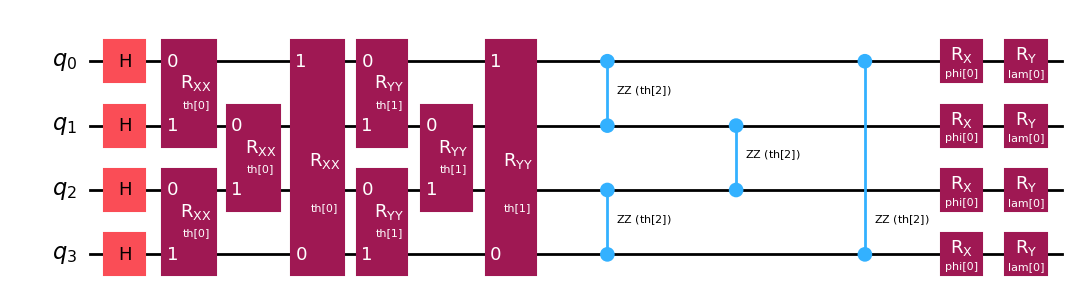

In [390]:
ansatz = get_relaxed_PBC_symm_ansatz(N, num_layers=1)
ansatz.draw('mpl') 

## OBC ansatz

In [26]:
def get_OBC_symm_ansatz(N, num_layers=1):
    """Symmetry-preserving ansatz for the transverse field Ising model with open boundary conditions.
    
    Args:
        N (int): Number of qubits (spins).
        num_layers (int): Number of layers in the ansatz.
        Returns: Parametrized QuantumCircuit object representing the ansatz."""
    num_gates_per_layer = 3  # Rxx, Ryy, Rzz
    theta = ParameterVector('th', num_gates_per_layer * num_layers)
    lam = ParameterVector('lam', num_gates_per_layer * num_layers)
    phi = ParameterVector('phi', num_layers)

    symm_ansatz = QuantumCircuit(N)

    symm_ansatz.h([n for n in range(N)])
    
    gate_labels = ["xx", "yy", "zz"]
    for layer in range(num_layers):
        for gate in gate_labels:
            # Apply nearest-neighbor gates in brick structure

            # Even to odd connections
            for n in range(N //2):
                param_index = layer * num_gates_per_layer + gate_labels.index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n, 2*n+1)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n, 2*n+1)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n, 2*n+1)
            # Odd to even connections
            for n in range(1, N //2 +1):
                param_index = layer * num_gates_per_layer + gate_labels.index(gate)
                param = theta[param_index]
                
                if gate == "xx":
                    symm_ansatz.rxx(param, 2*n-1, (2*n)%N)
                elif gate == "yy":
                    symm_ansatz.ryy(param, 2*n-1, (2*n)%N)
                elif gate == "zz":
                    symm_ansatz.rzz(param, 2*n-1, (2*n)%N)
    
        symm_ansatz.barrier()
    
        params = [lam[i + num_gates_per_layer*layer] for i in range(num_gates_per_layer)]

        for n in range(int(N//2)):
            # Apply long-range gates between qubits n and N-1-n (motivated by reflection symmetry of the Hamiltonian)

            if n == N-1-n:
                pass
            else:
                symm_ansatz.rzz(params[0], n, N-1-n)
                symm_ansatz.ryy(params[1], n, N-1-n)
                symm_ansatz.rxx(params[2], n, N-1-n)
                
        # Apply RX gates
        symm_ansatz.rx(phi[layer], [n for n in range(N)])

    return symm_ansatz



In [27]:
ansatz = get_OBC_symm_ansatz(N, num_layers=1)
ansatz.draw()

┌───┐┌─────────────┐               ┌─────────────┐┌─────────────┐»
q_0: ┤ H ├┤0            ├───────────────┤1            ├┤0            ├»
     ├───┤│  Rxx(th[0]) │┌─────────────┐│             ││  Ryy(th[1]) │»
q_1: ┤ H ├┤1            ├┤0            ├┤             ├┤1            ├»
     ├───┤├─────────────┤│  Rxx(th[0]) ││  Rxx(th[0]) │├─────────────┤»
q_2: ┤ H ├┤0            ├┤1            ├┤             ├┤0            ├»
     ├───┤│  Rxx(th[0]) │└─────────────┘│             ││  Ryy(th[1]) │»
q_3: ┤ H ├┤1            ├───────────────┤0            ├┤1            ├»
     └───┘└─────────────┘               └─────────────┘└─────────────┘»
«                    ┌─────────────┐                                     ░ »
«q_0: ───────────────┤1            ├─■───────────────────────■───────────░─»
«     ┌─────────────┐│             │ │ZZ(th[2])              │           ░ »
«q_1: ┤0            ├┤             ├─■───────────■───────────┼───────────░─»
«     │  Ryy(th[1]) ││  Ryy(th[1]) │             │ZZ(th[2])  │           ░ »
«q_2: ┤1            ├┤             ├─■───────────■───────────┼───────────░─»
«     └─────────────┘│             │ │ZZ(th[2])              │ZZ(th[2])  ░ »
«q_3: ───────────────┤0            ├─■───────────────────────■───────────░─»
«                    └─────────────┘                                     ░ »
«                               ┌──────────────┐                »
«q_0: ─■────────────────────────┤0             ├────────────────»
«      │                        │              │┌──────────────┐»
«q_1: ─┼────────────■───────────┤              ├┤0             ├»
«      │            │ZZ(lam[0]) │  Ryy(lam[1]) ││  Ryy(lam[1]) │»
«q_2: ─┼────────────■───────────┤              ├┤1             ├»
«      │ZZ(lam[0])              │              │└──────────────┘»
«q_3: ─■────────────────────────┤1             ├────────────────»
«                               └──────────────┘                »
«     ┌──────────────┐ ┌────────────┐               
«q_0: ┤0             ├─┤ Rx(phi[0]) ├───────────────
«     │              │┌┴────────────┴┐┌────────────┐
«q_1: ┤              ├┤0             ├┤ Rx(phi[0]) ├
«     │  Rxx(lam[2]) ││  Rxx(lam[2]) │├────────────┤
«q_2: ┤              ├┤1             ├┤ Rx(phi[0]) ├
«     │              │└┬────────────┬┘└────────────┘
«q_3: ┤1             ├─┤ Rx(phi[0]) ├───────────────
«     └──────────────┘ └────────────┘

In [14]:
ansatz = get_OBC_symm_ansatz(N, num_layers=1)
ansatz.draw()

┌───┐            ┌─────────────┐┌─────────────┐                           »
q_0: ┤ H ├─■──────────┤0            ├┤0            ├───────────────────────────»
     ├───┤ │ZZ(th[2]) │  Ryy(th[1]) ││  Rxx(th[0]) │            ┌─────────────┐»
q_1: ┤ H ├─■──────────┤1            ├┤1            ├─■──────────┤0            ├»
     ├───┤            ├─────────────┤├─────────────┤ │ZZ(th[2]) │  Ryy(th[1]) │»
q_2: ┤ H ├─■──────────┤0            ├┤0            ├─■──────────┤1            ├»
     ├───┤ │ZZ(th[2]) │  Ryy(th[1]) ││  Rxx(th[0]) │            └─────────────┘»
q_3: ┤ H ├─■──────────┤1            ├┤1            ├───────────────────────────»
     └───┘            └─────────────┘└─────────────┘                           »
«                     ░                           ┌──────────────┐»
«q_0: ────────────────░──■────────────────────────┤0             ├»
«     ┌─────────────┐ ░  │                        │              │»
«q_1: ┤0            ├─░──┼────────────■───────────┤              ├»
«     │  Rxx(th[0]) │ ░  │            │ZZ(lam[0]) │  Ryy(lam[1]) │»
«q_2: ┤1            ├─░──┼────────────■───────────┤              ├»
«     └─────────────┘ ░  │ZZ(lam[0])              │              │»
«q_3: ────────────────░──■────────────────────────┤1             ├»
«                     ░                           └──────────────┘»
«                     ┌──────────────┐ ┌────────────┐               
«q_0: ────────────────┤0             ├─┤ Rx(phi[0]) ├───────────────
«     ┌──────────────┐│              │┌┴────────────┴┐┌────────────┐
«q_1: ┤0             ├┤              ├┤0             ├┤ Rx(phi[0]) ├
«     │  Ryy(lam[1]) ││  Rxx(lam[2]) ││  Rxx(lam[2]) │├────────────┤
«q_2: ┤1             ├┤              ├┤1             ├┤ Rx(phi[0]) ├
«     └──────────────┘│              │└┬────────────┬┘└────────────┘
«q_3: ────────────────┤1             ├─┤ Rx(phi[0]) ├───────────────
«                     └──────────────┘ └────────────┘

In [392]:
def cost_func(params, ansatz, hamiltonian, estimator):
    """Return estimate of energy from estimator

    Parameters:
        params (ndarray): Array of ansatz parameters
        ansatz (QuantumCircuit): Parameterized ansatz circuit
        hamiltonian (SparsePauliOp): Operator representation of Hamiltonian
        estimator (EstimatorV2): Estimator primitive instance
        g (float): Transverse field strength
    Returns:
        float: Energy estimate
    """

    pub = (ansatz, [hamiltonian], params)
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    energy = result.data.evs[0]
    
    
    return energy

In [393]:
def store_intermediate_result(intermediate_result: OptimizeResult):
    
    params = intermediate_result.x # array of parameters at the intermediate iteration
    energy = intermediate_result.fun # cost function value at this iteration

    cost_history_dict[str(g)]["iters"] += 1
    cost_history_dict[str(g)]["prev_vector"] = params
    cost_history_dict[str(g)]["cost_history"].append(energy)
    print(f"g={g} Iters. done: {cost_history_dict[str(g)]['iters']} [Current cost: {energy}]", 
            end="\r",
            flush=True)


In [394]:
def get_vqe_gs(hamiltonian, ansatz, estimator, num_runs=3):

    num_params = ansatz.num_parameters
    
    x0 = 0.01 * np.random.randn(num_params)   # near zero
    estimator.options.default_shots = 5000
    options = {'maxiter': 5000, 'rhobeg': 0.1, 'tol': 1e-6}
    
    # Run VQE num_runs times with different initial parameters and take the best result
    energy = np.inf
    for seed in range(num_runs):
        x0 = 0.01 * np.random.randn(num_params)   # near zero
        res = minimize(
            cost_func,
            x0,
            args=(ansatz, hamiltonian, estimator),
            method="cobyla",  
            options=options,
            callback=store_intermediate_result
        )
        if res.fun < energy:
            energy = res.fun
            final_params = res.x

    return energy, final_params

In [410]:
E_GS_qiskit = []
psi_GS_qiskit = []
circuit_vqe_list = []
E_sq_qiskit_list = []

#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["prev_vector", "iters", "cost_history"]

cost_history_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["prev_vector"] = None
    cost_history_dict[outter_key]["iters"] = 0
    cost_history_dict[outter_key]["cost_history"] = []
"""
if PBC:
    ansatz = get_PBC_symm_ansatz(N, num_layers=N//2)
else:
    ansatz = get_OBC_symm_ansatz(N, num_layers=N//2)
"""

ansatz = get_relaxed_PBC_symm_ansatz(N, num_layers=N//2)
   
for g in gs:

    hamiltonian = H_tfi(N, J=1.0, g=g, PBC=PBC)
    
    
    """
    # Hamiltonian Variational Ansatz (HVA)
    plus = QuantumCircuit(N)
    plus.h([n for n in range(N)])
    hva = hamiltonian_variational_ansatz(hamiltonian=hamiltonian, reps=N)
    ansatz = plus.compose(hva)
    """
    
    E_vqe, params = get_vqe_gs(hamiltonian, ansatz, estimator, num_runs=5)
    circuit_vqe = ansatz.assign_parameters(params)
    psi_vqe = Statevector(circuit_vqe)
    
    E_GS_qiskit.append(E_vqe)
    psi_GS_qiskit.append(psi_vqe)
    circuit_vqe_list.append(circuit_vqe)
    
    
    """Calcaulate <H^2>"""
    """
    hamiltonian_sq = hamiltonian @ hamiltonian
    hamiltonian_sq = hamiltonian_sq.simplify()
    estimator.options.default_shots = 5000
    pub = (circuit_vqe, [hamiltonian_sq])
    job = estimator.run([pub], precision=1e-6)
    result = job.result()[0]
    E_sq_vqe = result.data.evs[0]
    E_sq_qiskit_list.append(E_sq_vqe)
    """

    
    

## Compare with Quspin

In [411]:
import numpy as np # generic math functions
#from scipy.optimize import curve_fit
#from scipy.special import ellipk, factorial
#from scipy.integrate import quad

import matplotlib.pyplot as plt # plotting library
#plt.rcParams["text.usetex"] = True


import time, itertools
import sys,os
os.environ['OMP_NUM_THREADS'] = '8'
os.environ['MLK_NUM_THREADS'] = '8'

from quspin.operators import hamiltonian, quantum_operator, exp_op # Hamiltonians and operators
from quspin.basis import tensor_basis, spin_basis_1d, boson_basis_1d, boson_basis_general  # Hilbert space bases
from quspin.tools.measurements import ED_state_vs_time, obs_vs_time
from quspin.tools.evolution import evolve

import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection


In [412]:
##### define model parameters #####

def H_tfi_quspin(N, J=1.0, g=0.0, PBC=False): 

    h_field=[[-g,i] for i in range(N)]
    if PBC:
        J_zz=[[-J, i, (i+1) % N] for i in range(N)]
    else:
        J_zz=[[-J, i, i+1] for i in range(N-1)] 
    static_spin = [["zz",J_zz],["x",h_field]]
    dynamic_spin = []
    basis_spin = spin_basis_1d(L=N)
    
    H_spin=hamiltonian(static_spin, dynamic_spin, basis=basis_spin, dtype=np.complex64, check_herm=False, check_symm=False)
    return H_spin

In [413]:

E_GS_quspin = []
psi_GS_quspin = []
dense = True

for g in gs:
    H = H_tfi_quspin(N, J=1.0, g=g, PBC=PBC)
    if dense:
        E, V = H.as_dense_format().eigh()
        V = V[:, 0]
    else:
        E, V = H.eigsh(k=1, which='SA')
    E_GS_quspin.append(E[0])
    psi_GS_quspin.append(V)


In [414]:
#var_E = np.array(E_sq_qiskit_list) - np.array(E_GS_qiskit)**2

#Fractional error
E_GS_quspin = np.array(E_GS_quspin)
error = np.abs((E_GS_quspin-E_GS_qiskit)/E_GS_quspin)

#Overlap
overlap_arr = np.zeros(len(gs))

for i in range(len(gs)):
    overlap_sqrt = np.abs(np.vdot(psi_GS_quspin[i], psi_GS_qiskit[i]))
    overlap_arr[i] = overlap_sqrt**2    

In [415]:
print(error)

[3.45130372e-06]


In [416]:
psi_GS_qiskit[0].draw('latex')

<IPython.core.display.Latex object>

In [417]:
Statevector(psi_GS_quspin[0]).draw('latex')

<IPython.core.display.Latex object>

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
/var/folders/26/3g2wy1kx0k72dhg7_ycw5c5c0000gr/T/ipykernel_13045/1360114565.py:25: SyntaxWarning: invalid escape sequence '\p'
  ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')


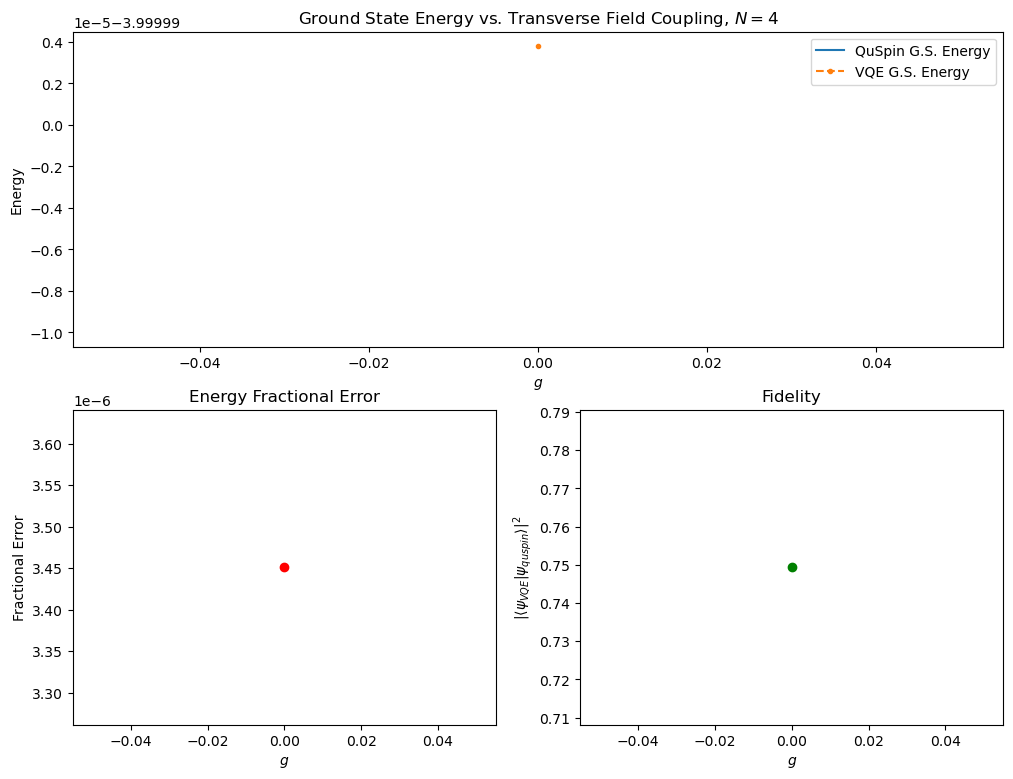

In [418]:
layout = [['A panel', 'A panel'],
         ['B panel', 'C panel',]]
fig, axd = plt.subplot_mosaic(layout, figsize=(12, 9))
ax1 = axd['A panel']
ax1.plot(gs, E_GS_quspin, label='QuSpin G.S. Energy')
ax1.plot(gs, E_GS_qiskit, '--.', label='VQE G.S. Energy')
#ax1.errorbar(gs, E_GS_qiskit, std_dev, color='black', alpha=1, label=r'$\sigma_{E}$ VQE', fmt='none')

ax1.set_title('Ground State Energy vs. Transverse Field Coupling, $N={}$'.format(N))
ax1.set_xlabel('$g$')
ax1.set_ylabel('Energy')
ax1.legend()

ax2 = axd['B panel']
ax2.plot(gs, error, '--o', color='red')
ax2.set_title('Energy Fractional Error')
ax2.set_xlabel('$g$')
ax2.set_ylabel('Fractional Error')

ax3 = axd['C panel']
ax3.plot(gs, overlap_arr, '--o', color='green')

ax3.set_title('Fidelity')
ax3.set_xlabel('$g$')
ax3.set_ylabel('$|\\langle \psi_{VQE} | \psi_{quspin} \\rangle |^2$')

fname = "TFI_VQE_plots_N={}_ansatz=hvaPBC_layers={}".format(N, N//2)
#plt.savefig(fname + '.pdf')

#ansatz.draw('mpl').savefig(circuit_fname + '.pdf')


plt.show()

## Estimator variance

In [419]:
#Initialize cost history dictionary
outter_keys = [str(g) for g in gs]
inner_keys = ["energy", "mean", "std_dev"]

E_vqe_dict = {}
for outter_key in outter_keys:
    cost_history_dict[outter_key] = {}
    cost_history_dict[outter_key]["energy"] = np.zeros(10)
    cost_history_dict[outter_key]["mean"] = 0
    cost_history_dict[outter_key]["std_dev"] = 0


In [420]:
num_samples = 5
E_vqe_sample = np.zeros((len(gs), num_samples))
E_sample_mean = np.zeros(len(gs))
E_sample_std = np.zeros(len(gs))

for j, g in enumerate(gs):
    for i in range(num_samples):
        hamiltonian = H_tfi(N, J=1.0, g=g, PBC=PBC)
        #estimator.options.default_shots = 500
        pub = (circuit_vqe_list[j], [hamiltonian])
        job = estimator.run([pub], precision=1e-6)
        result = job.result()[0]
        E_vqe_sample[j, i] = result.data.evs[0]
    
    E_sample_mean[j] = np.mean(E_vqe_sample[j, :])
    E_sample_std[j] = np.std(E_vqe_sample[j, :], ddof=1)

In [421]:
E_sample_std

array([6.38157775e-07])

In [422]:
E_sample_mean

array([-3.99998278])